In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import math
import os
import warnings
import requests
from bs4 import BeautifulSoup
from scipy import stats
from scipy.stats import ttest_ind
from io import StringIO

In [3]:
#data from json file

data_folder = './data/newyorker_caption_contest/'
df = pd.read_json(data_folder + 'contests.json')
metadata = df['metadata'].apply(pd.Series)
df = pd.concat([df.drop(columns=['metadata']), metadata], axis=1)

df.head(10)

,contest_id,image,data,num_captions,num_votes,image_locations,image_descriptions,image_uncanny_descriptions,entities,questions
0,510,images/510.jpg,data/510.csv,3905.0,41185.0,[the street],[A man is relaxing on a city street. Others ar...,[A man is just laying in the middle of the sid...,[https://en.wikipedia.org/wiki/Bystander_effec...,[Why is he laying there?]
1,511,images/511.jpg,data/511.csv,3325.0,28205.0,"[the front hard, a residential walkway]",[A man in a winter coat and cap is looking at ...,[It's unusual to see someone holding a snow sh...,"[https://en.wikipedia.org/wiki/Snowball_fight,...",[Is the man overly small or the shovel overly ...
2,512,images/512.jpg,data/512.csv,4399.0,21574.0,"[yoga place, a yoga studio]",[A man and woman are standing facing one anoth...,[Nothing is really out of place in this image....,"[https://en.wikipedia.org/wiki/Rug, https://en...","[Why is the man carrying a huge rug?, Why is t..."
3,513,images/513.jpg,data/513.csv,4141.0,16894.0,"[a workplace, an elevator]",[Three business men are walking down a hall. T...,[A suit case is usually carried by one person ...,[https://en.wikipedia.org/wiki/Worker_cooperat...,[Why is the briefcase big enough for three peo...
4,514,images/514.jpg,data/514.csv,3951.0,95790.0,[plains],[Some cowboys are riding through the desert. T...,[There are rocking horses in place of real hor...,"[https://en.wikipedia.org/wiki/Rocking_horse, ...",[Why is this chase taking place?]
5,515,images/515.jpg,data/515.csv,4270.0,23543.0,"[a railroad, a subway]",[People are laying on the subway tracks as an ...,[They are putting themselves in danger by bein...,"[https://en.wikipedia.org/wiki/Train, https://...","[Why are they bandaged up?, What caused their ..."
6,516,images/516.jpg,data/516.csv,5918.0,24660.0,"[restaurant, a restaurant]",[A couple is having drinks at a table when a c...,[The cinderblock is coming out of nowhere and ...,"[https://en.wikipedia.org/wiki/Safety, https:/...",[Why is a cement block falling from the ceilin...
7,517,images/517.jpg,data/517.csv,7782.0,29913.0,[a courtroom],[A lawyer is with his client in a courtroom. T...,[The client is Death.],"[https://en.wikipedia.org/wiki/Lawyer, https:/...",[How do you arrest Death?]
8,518,images/518.jpg,data/518.csv,4509.0,123937.0,"[top of building, a rooftop]",[A man is crawling across a sandbox. Two kids ...,[There is an adult man in a sandbox for kids. ...,"[https://en.wikipedia.org/wiki/Sandpit, https:...","[Why is the man crawling around the sandbox?, ..."
9,519,images/519.jpg,data/519.csv,4614.0,96184.0,"[woodlands, forest]",[Two pheasants are together watching a hunter....,[Birds would be too scared to stay on the gun....,"[https://en.wikipedia.org/wiki/Bird, https://e...","[Why is the bird on the gun?, Why is the bird ..."


In [4]:
#scrape data from caption contest website

url = "https://nextml.github.io/caption-contest-data/"
soup = BeautifulSoup(requests.get(url).content, 'html.parser')

df_scrape = pd.read_html(StringIO(str(soup.find('table'))))[0]
df_scrape

,Contest Dashboard,Cartoon,Top Rated caption,The New Yorker's winner,Finalists Announced (date of issue),Number of votes
0,895 Dashboard,NaN,“Do you think death rays would be considered e...,NaN,NaN,777820
1,894 Dashboard,NaN,“See how the nose seems to follow you?”,NaN,NaN,878676
2,893 Dashboard,NaN,“The seller isn't willing to come down.”,NaN,NaN,1085745
3,892 Dashboard,NaN,"“Yes, it's called Thesaurus, but you're not re...",NaN,NaN,788251
4,891 Dashboard,NaN,"“Sorry, only the catcher works from home.”",NaN,NaN,928856
...,...,...,...,...,...,...
380,514 Dashboard,NaN,"“No, you grow up”",NaN,2016-04-03 (estimated),192198
381,513 Dashboard,NaN,"“I'm just saying, I can see why the 'brief'cas...",NaN,2016-03-27 (estimated),34013
382,512 Dashboard,NaN,"“We're pretentious, not ostentatious.”",NaN,2016-03-21 (estimated),43120
383,511 Dashboard,NaN,“I'm hourly.”,NaN,NaN,56660


In [5]:
#clean df_scrape columns

df_scrape['Contest Dashboard'] = df_scrape['Contest Dashboard'].str.replace(' Dashboard', '').str.strip()
df_scrape.rename(columns={'Finalists Announced (date of issue)': 'Date'}, inplace=True)
df_scrape['Date'] = df_scrape['Date'].str.replace(' (estimated)', '').str.strip()
df_scrape.drop(columns=['Cartoon'], inplace=True)
df_scrape = df_scrape.iloc[::-1].reset_index(drop=True)
df_scrape.head(100)

,Contest Dashboard,Top Rated caption,The New Yorker's winner,Date,Number of votes
0,510,“I'm a congressman--obstruction is my job.”,NaN,NaN,82627
1,511,“I'm hourly.”,NaN,NaN,56660
2,512,"“We're pretentious, not ostentatious.”",NaN,2016-03-21,43120
3,513,"“I'm just saying, I can see why the 'brief'cas...",NaN,2016-03-27,34013
4,514,"“No, you grow up”",NaN,2016-04-03,192198
...,...,...,...,...,...
95,606,“As senior squeegee-man during flight simulati...,NaN,NaN,46951
96,607,“My only regret is that he never got around to...,NaN,NaN,1026981
97,608,“The hard part was transposing from C major to...,NaN,NaN,957697
98,609,“He really did appoint Chris Christie as Secre...,NaN,NaN,1046199


In [6]:
#check if all expected contest IDs are present
expected_ids = list(range(510, 896))
missing_ids_df = pd.Series(expected_ids)[~pd.Series(expected_ids).isin(df['contest_id'])]
missing_ids_scrape = pd.Series(expected_ids)[~pd.Series(expected_ids).isin(df_scrape['Contest Dashboard'].astype(int))]

print('Missing data from df: ',missing_ids_df.tolist())
print('Missing data from df_scrape: ',missing_ids_scrape.tolist())

Missing data from df:  [525, 540]
Missing data from df_scrape:  [525]


what to do now ? shift all ids or not ?

In [7]:
from datetime import timedelta

df_scrape['Date'] = pd.to_datetime(df_scrape['Date'], errors='coerce')

# Assume contest happens each week and fill missing dates
for i in range(1, len(df_scrape)):
    if pd.isna(df_scrape.loc[i, 'Date']):
        df_scrape.loc[i, 'Date'] = df_scrape.loc[i - 1, 'Date'] + timedelta(days=7)

for i in range(len(df_scrape)-2, -1, -1):
    if pd.isna(df_scrape.loc[i, 'Date']):
        df_scrape.loc[i, 'Date'] = df_scrape.loc[i+1, 'Date'] - timedelta(days=7)
    
df_scrape

,Contest Dashboard,Top Rated caption,The New Yorker's winner,Date,Number of votes
0,510,“I'm a congressman--obstruction is my job.”,NaN,2016-03-07,82627
1,511,“I'm hourly.”,NaN,2016-03-14,56660
2,512,"“We're pretentious, not ostentatious.”",NaN,2016-03-21,43120
3,513,"“I'm just saying, I can see why the 'brief'cas...",NaN,2016-03-27,34013
4,514,"“No, you grow up”",NaN,2016-04-03,192198
...,...,...,...,...,...
380,891,"“Sorry, only the catcher works from home.”",NaN,2023-08-21,928856
381,892,"“Yes, it's called Thesaurus, but you're not re...",NaN,2023-08-28,788251
382,893,“The seller isn't willing to come down.”,NaN,2023-09-04,1085745
383,894,“See how the nose seems to follow you?”,NaN,2023-09-11,878676


## Dataframe complet (mais pas clean)

In [8]:
df_scrape['Contest Dashboard'] = df_scrape['Contest Dashboard'].astype(int)
df_complete = pd.merge(df, df_scrape, left_on='contest_id', right_on='Contest Dashboard')

df_complete.drop(columns=['image'], inplace=True)
df_complete.drop(columns=['data'], inplace=True)
df_complete.drop(columns=['Contest Dashboard'], inplace=True)
df_complete.drop(columns=['num_votes'], inplace=True) #better to keep Number of Votes from the official website
df_complete.head(10)

,contest_id,num_captions,image_locations,image_descriptions,image_uncanny_descriptions,entities,questions,Top Rated caption,The New Yorker's winner,Date,Number of votes
0,510,3905.0,[the street],[A man is relaxing on a city street. Others ar...,[A man is just laying in the middle of the sid...,[https://en.wikipedia.org/wiki/Bystander_effec...,[Why is he laying there?],“I'm a congressman--obstruction is my job.”,NaN,2016-03-07,82627
1,511,3325.0,"[the front hard, a residential walkway]",[A man in a winter coat and cap is looking at ...,[It's unusual to see someone holding a snow sh...,"[https://en.wikipedia.org/wiki/Snowball_fight,...",[Is the man overly small or the shovel overly ...,“I'm hourly.”,NaN,2016-03-14,56660
2,512,4399.0,"[yoga place, a yoga studio]",[A man and woman are standing facing one anoth...,[Nothing is really out of place in this image....,"[https://en.wikipedia.org/wiki/Rug, https://en...","[Why is the man carrying a huge rug?, Why is t...","“We're pretentious, not ostentatious.”",NaN,2016-03-21,43120
3,513,4141.0,"[a workplace, an elevator]",[Three business men are walking down a hall. T...,[A suit case is usually carried by one person ...,[https://en.wikipedia.org/wiki/Worker_cooperat...,[Why is the briefcase big enough for three peo...,"“I'm just saying, I can see why the 'brief'cas...",NaN,2016-03-27,34013
4,514,3951.0,[plains],[Some cowboys are riding through the desert. T...,[There are rocking horses in place of real hor...,"[https://en.wikipedia.org/wiki/Rocking_horse, ...",[Why is this chase taking place?],"“No, you grow up”",NaN,2016-04-03,192198
5,515,4270.0,"[a railroad, a subway]",[People are laying on the subway tracks as an ...,[They are putting themselves in danger by bein...,"[https://en.wikipedia.org/wiki/Train, https://...","[Why are they bandaged up?, What caused their ...",“Tell me about your childhood very quickly.”,NaN,2016-04-10,47448
6,516,5918.0,"[restaurant, a restaurant]",[A couple is having drinks at a table when a c...,[The cinderblock is coming out of nowhere and ...,"[https://en.wikipedia.org/wiki/Safety, https:/...",[Why is a cement block falling from the ceilin...,“I have no concrete plans for the rest of the ...,NaN,2016-04-17,49365
7,517,7782.0,[a courtroom],[A lawyer is with his client in a courtroom. T...,[The client is Death.],"[https://en.wikipedia.org/wiki/Lawyer, https:/...",[How do you arrest Death?],“Who'd have thought they'd get you for tax eva...,NaN,2016-04-24,59717
8,518,4509.0,"[top of building, a rooftop]",[A man is crawling across a sandbox. Two kids ...,[There is an adult man in a sandbox for kids. ...,"[https://en.wikipedia.org/wiki/Sandpit, https:...","[Why is the man crawling around the sandbox?, ...",“This saddest part is he's going in the wrong ...,NaN,2016-05-01,248180
9,519,4614.0,"[woodlands, forest]",[Two pheasants are together watching a hunter....,[Birds would be too scared to stay on the gun....,"[https://en.wikipedia.org/wiki/Bird, https://e...","[Why is the bird on the gun?, Why is the bird ...","“He's pro-gun, but I like his stance on migrat...",NaN,2016-05-08,191935


In [9]:
def separate(df, col):
    '''
    Create a new dataframe by exploding and isolating a specific column.
    
    Parameters:
    df (pd.DataFrame): The original dataframe.
    col (str): The column to explode and isolate.
    
    Return:
    pd.DataFrame: A new dataframe with 'contest_id' matching the specified column.
    '''
    
    df_new = df.explode(col)
    return df_new[['contest_id', col]]

## Dataframes clean et séparés

In [10]:
#separate dataframes
df_base = df_complete[['contest_id', 'num_captions', 'Number of votes', 'Date', 'Top Rated caption', "The New Yorker's winner"]]
df_locations = separate(df_complete, 'image_locations')
df_descriptions = separate(df_complete, 'image_descriptions')
df_uncanny = separate(df_complete, 'image_uncanny_descriptions')
df_entities = separate(df_complete, 'entities')
df_questions = separate(df_complete, 'questions')

df_base.head(20)

,contest_id,num_captions,Number of votes,Date,Top Rated caption,The New Yorker's winner
0,510,3905.0,82627,2016-03-07,“I'm a congressman--obstruction is my job.”,NaN
1,511,3325.0,56660,2016-03-14,“I'm hourly.”,NaN
2,512,4399.0,43120,2016-03-21,"“We're pretentious, not ostentatious.”",NaN
3,513,4141.0,34013,2016-03-27,"“I'm just saying, I can see why the 'brief'cas...",NaN
4,514,3951.0,192198,2016-04-03,"“No, you grow up”",NaN
5,515,4270.0,47448,2016-04-10,“Tell me about your childhood very quickly.”,NaN
6,516,5918.0,49365,2016-04-17,“I have no concrete plans for the rest of the ...,NaN
7,517,7782.0,59717,2016-04-24,“Who'd have thought they'd get you for tax eva...,NaN
8,518,4509.0,248180,2016-05-01,“This saddest part is he's going in the wrong ...,NaN
9,519,4614.0,191935,2016-05-08,"“He's pro-gun, but I like his stance on migrat...",NaN


In [11]:
#df_entities : clean column

df_entities['entities'] = df_entities['entities'].str.replace('https://en.wikipedia.org/wiki/', '').str.strip()
df_entities['entities'] = df_entities['entities'].str.replace('_', ' ').str.strip()
df_entities

,contest_id,entities
0,510,Bystander effect
0,510,Crowd
1,511,Snowball fight
1,511,Winter
1,511,Snow removal
...,...,...
379,891,NaN
380,892,NaN
381,893,NaN
382,894,NaN


# LLM Humor & Sentiment Distribution

In this section, we visualize the **distribution of humor types** and **sentiment polarity** predicted by the LLMs for each field of the *Cartoon Caption Contest* dataset (`image_descriptions`, `image_uncanny_descriptions`, and `questions`).  
Each pie chart shows the proportion of categories — using short two-letter codes (e.g., **IR** for *Irony*, **SA** for *Sarcasm*, **PO** for *Positive*, **NE** for *Negative*).  
This helps us understand which kinds of humor and emotional tones dominate across the dataset.

In [12]:
# --- Safety: recreate clean exploded DFs if they don't exist, then merge with LLM outputs ---

import pandas as pd
import json, pathlib

# 1) Recreate df_descriptions / df_uncanny / df_questions if missing
def ensure_clean_dfs():
    missing = [name for name in ["df_descriptions","df_uncanny","df_questions"] if name not in globals()]
    if missing:
        # need df_complete and separate()
        assert "df_complete" in globals(), "Run the cells that build `df_complete` first."
        assert "separate" in globals(), "Run the cell that defines `separate(df, col)` first."
        globals()["df_descriptions"] = separate(df_complete, "image_descriptions")
        globals()["df_uncanny"]      = separate(df_complete, "image_uncanny_descriptions")
        globals()["df_questions"]    = separate(df_complete, "questions")

ensure_clean_dfs()

# 2) Load LLM-enriched JSON and build tidy frames per field
PATH_LLM = pathlib.Path("data/newyorker_caption_contest/contests_with_humor.json")
raw = json.loads(PATH_LLM.read_text(encoding="utf-8"))
contests = raw["contests"] if isinstance(raw, dict) else raw

SAFE_CLASSES = {"irony","sarcasm","exaggeration","incongruity-absurdity","self-deprecating","wit-surprise","unknown"}
SAFE_SENT   = {"positive","neutral","negative","unknown"}

def build_field_df(field):
    rows = []
    for rec in contests:
        cid = rec.get("contest_id")
        meta = rec.get("metadata", {}) or {}
        texts = meta.get(field, []) or []
        llm_block = meta.get("llm_humor_labels", {}) or {}
        sent_block= meta.get("llm_sentiment", {}) or {}
        humor_labels = llm_block.get(field, []) or []
        sent_labels  = sent_block.get(field, []) or []
        for pos, txt in enumerate(texts):
            humor = humor_labels[pos] if pos < len(humor_labels) else "unknown"
            sent  = sent_labels[pos]  if pos < len(sent_labels)  else "unknown"
            humor = humor if humor in SAFE_CLASSES else "unknown"
            sent  = sent  if sent  in SAFE_SENT   else "unknown"
            rows.append({"contest_id": cid, "pos": pos, "text": txt, "humor_label": humor, "sentiment": sent})
    return pd.DataFrame(rows)

llm_desc     = build_field_df("image_descriptions")
llm_uncanny  = build_field_df("image_uncanny_descriptions")
llm_questions= build_field_df("questions")

# 3) Add positional index to your clean DFs and merge
def with_pos(df, colname):
    out = df.copy()
    out["pos"] = out.groupby("contest_id").cumcount()
    return out.rename(columns={colname: "text_clean"})

desc_pos    = with_pos(df_descriptions, "image_descriptions")
uncanny_pos = with_pos(df_uncanny, "image_uncanny_descriptions")
quest_pos   = with_pos(df_questions, "questions")

desc_llm = desc_pos.merge(llm_desc, on=["contest_id","pos"], how="left", validate="one_to_one")
uncanny_llm = uncanny_pos.merge(llm_uncanny, on=["contest_id","pos"], how="left", validate="one_to_one")
questions_llm = quest_pos.merge(llm_questions, on=["contest_id","pos"], how="left", validate="one_to_one")

# 4) Tidy columns + peek
desc_llm = desc_llm[["contest_id","pos","text_clean","text","humor_label","sentiment"]]
uncanny_llm = uncanny_llm[["contest_id","pos","text_clean","text","humor_label","sentiment"]]
questions_llm = questions_llm[["contest_id","pos","text_clean","text","humor_label","sentiment"]]

print("desc_llm:", desc_llm.shape, "  uncanny_llm:", uncanny_llm.shape, "  questions_llm:", questions_llm.shape)
display(desc_llm.head(5))
display(uncanny_llm.head(5))
display(questions_llm.head(5))

desc_llm: (674, 6)   uncanny_llm: (674, 6)   questions_llm: (729, 6)


,contest_id,pos,text_clean,text,humor_label,sentiment
0,510,0,A man is relaxing on a city street. Others are...,A man is relaxing on a city street. Others are...,irony,neutral
1,511,0,A man in a winter coat and cap is looking at a...,A man in a winter coat and cap is looking at a...,unknown,neutral
2,511,1,A man is in the snow. A boy with a huge snow s...,A man is in the snow. A boy with a huge snow s...,unknown,neutral
3,511,2,A man is walking down a sidewalk. He is lookin...,A man is walking down a sidewalk. He is lookin...,unknown,neutral
4,512,0,A man and woman are standing facing one anothe...,A man and woman are standing facing one anothe...,sarcasm,negative


,contest_id,pos,text_clean,text,humor_label,sentiment
0,510,0,A man is just laying in the middle of the side...,A man is just laying in the middle of the side...,unknown,neutral
1,511,0,It's unusual to see someone holding a snow sho...,It's unusual to see someone holding a snow sho...,incongruity-absurdity,neutral
2,511,1,The boy has a huge snow shovel.,The boy has a huge snow shovel.,incongruity-absurdity,neutral
3,511,2,Nothing is out of place.,Nothing is out of place.,incongruity-absurdity,neutral
4,512,0,Nothing is really out of place in this image.,Nothing is really out of place in this image.,incongruity-absurdity,neutral


,contest_id,pos,text_clean,text,humor_label,sentiment
0,510,0,Why is he laying there?,Why is he laying there?,unknown,neutral
1,511,0,Is the man overly small or the shovel overly big?,Is the man overly small or the shovel overly big?,incongruity-absurdity,neutral
2,511,1,Why does the boy have a huge snow shovel?,Why does the boy have a huge snow shovel?,incongruity-absurdity,negative
3,511,2,What are they doing?,What are they doing?,unknown,neutral
4,511,3,What is the man in the foreground holding in h...,What is the man in the foreground holding in h...,unknown,neutral


In [13]:
# We keep your clean dataframes unchanged and just add a positional index
def with_pos(df, colname):
    # explode() already done in your code; ensure a stable order inside each contest
    out = df.copy()
    out["pos"] = out.groupby("contest_id").cumcount()
    out = out.rename(columns={colname: "text_clean"})
    return out

desc_pos    = with_pos(df_descriptions, "image_descriptions")
uncanny_pos = with_pos(df_uncanny, "image_uncanny_descriptions")
quest_pos   = with_pos(df_questions, "questions")

# Merge on (contest_id, pos)
desc_llm = (desc_pos
            .merge(llm_desc, on=["contest_id","pos"], how="left", validate="one_to_one"))
uncanny_llm = (uncanny_pos
               .merge(llm_uncanny, on=["contest_id","pos"], how="left", validate="one_to_one"))
questions_llm = (quest_pos
                 .merge(llm_questions, on=["contest_id","pos"], how="left", validate="one_to_one"))

# Columns order for readability
desc_llm = desc_llm[["contest_id","pos","text_clean","text","humor_label","sentiment"]]
uncanny_llm = uncanny_llm[["contest_id","pos","text_clean","text","humor_label","sentiment"]]
questions_llm = questions_llm[["contest_id","pos","text_clean","text","humor_label","sentiment"]]

print("desc_llm:", desc_llm.shape, "  uncanny_llm:", uncanny_llm.shape, "  questions_llm:", questions_llm.shape)
display(desc_llm.head(5))
display(uncanny_llm.head(5))
display(questions_llm.head(5))

desc_llm: (674, 6)   uncanny_llm: (674, 6)   questions_llm: (729, 6)


,contest_id,pos,text_clean,text,humor_label,sentiment
0,510,0,A man is relaxing on a city street. Others are...,A man is relaxing on a city street. Others are...,irony,neutral
1,511,0,A man in a winter coat and cap is looking at a...,A man in a winter coat and cap is looking at a...,unknown,neutral
2,511,1,A man is in the snow. A boy with a huge snow s...,A man is in the snow. A boy with a huge snow s...,unknown,neutral
3,511,2,A man is walking down a sidewalk. He is lookin...,A man is walking down a sidewalk. He is lookin...,unknown,neutral
4,512,0,A man and woman are standing facing one anothe...,A man and woman are standing facing one anothe...,sarcasm,negative


,contest_id,pos,text_clean,text,humor_label,sentiment
0,510,0,A man is just laying in the middle of the side...,A man is just laying in the middle of the side...,unknown,neutral
1,511,0,It's unusual to see someone holding a snow sho...,It's unusual to see someone holding a snow sho...,incongruity-absurdity,neutral
2,511,1,The boy has a huge snow shovel.,The boy has a huge snow shovel.,incongruity-absurdity,neutral
3,511,2,Nothing is out of place.,Nothing is out of place.,incongruity-absurdity,neutral
4,512,0,Nothing is really out of place in this image.,Nothing is really out of place in this image.,incongruity-absurdity,neutral


,contest_id,pos,text_clean,text,humor_label,sentiment
0,510,0,Why is he laying there?,Why is he laying there?,unknown,neutral
1,511,0,Is the man overly small or the shovel overly big?,Is the man overly small or the shovel overly big?,incongruity-absurdity,neutral
2,511,1,Why does the boy have a huge snow shovel?,Why does the boy have a huge snow shovel?,incongruity-absurdity,negative
3,511,2,What are they doing?,What are they doing?,unknown,neutral
4,511,3,What is the man in the foreground holding in h...,What is the man in the foreground holding in h...,unknown,neutral


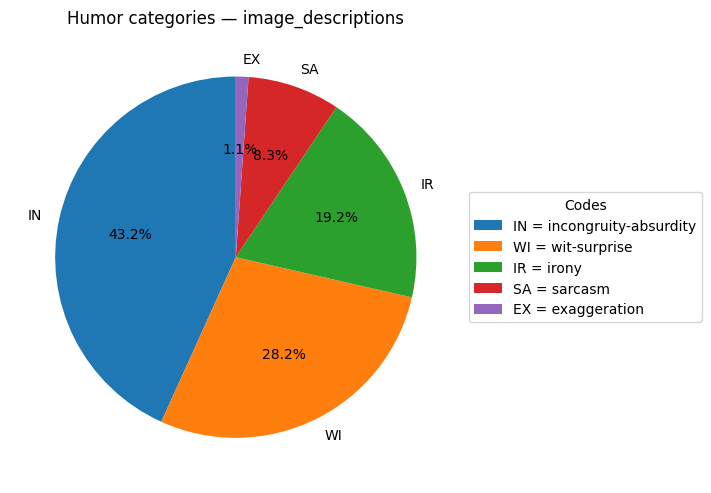

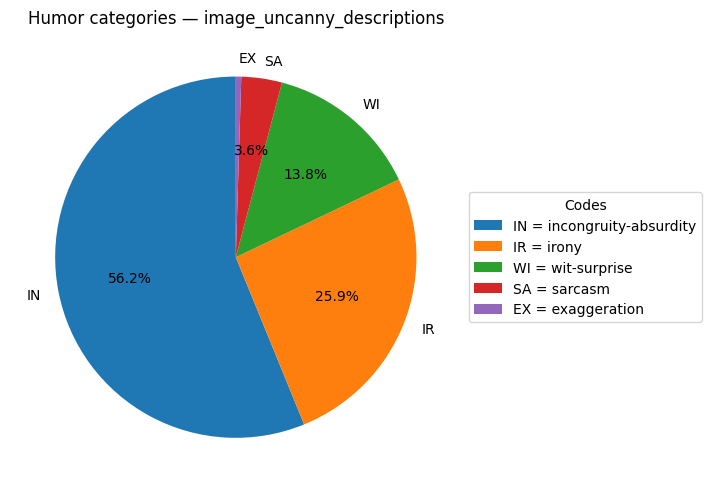

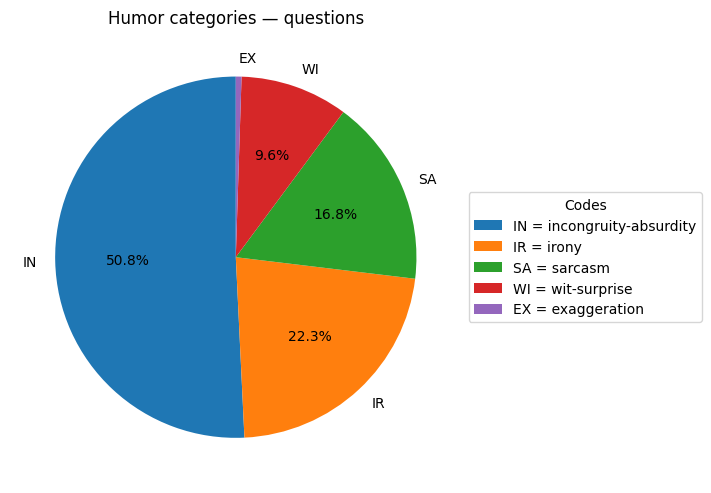

In [26]:
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

INCLUDE_UNKNOWN = False
MIN_SLICE_COUNT = 1

# Map dataset field -> (clean_df, text_column, llm_df)
FIELD_MAP = {
    "image_descriptions":          (df_descriptions,           "image_descriptions",          desc_llm),
    "image_uncanny_descriptions":  (df_uncanny,                "image_uncanny_descriptions",  uncanny_llm),
    "questions":                   (df_questions,              "questions",                   questions_llm),
}

# Which column in your LLM dfs holds the HUMOR class
POSSIBLE_HUMOR_COLS = ["label", "humor", "humor_label", "pred", "prediction"]

def pick_humor_col(df: pd.DataFrame) -> str:
    for c in POSSIBLE_HUMOR_COLS:
        if c in df.columns:
            return c
    # fallback to first string-ish non-key column
    for c in df.columns:
        if c not in {"contest_id", "idx"} and pd.api.types.is_string_dtype(df[c]):
            return c
    raise ValueError("No humor label column found in the LLM dataframe.")

# Normalize model outputs to the 6 official class names; else 'unknown'
CLASSES = {
    "irony": "irony",
    "sarcasm": "sarcasm",
    "exaggeration": "exaggeration",
    "incongruity-absurdity": "incongruity-absurdity",
    "incongruity absurdity": "incongruity-absurdity",
    "self-deprecating": "self-deprecating",
    "self deprecating": "self-deprecating",
    "wit-surprise": "wit-surprise",
    "wit": "wit-surprise",
}
def normalize_humor(x: str) -> str:
    if not isinstance(x, str):
        return "unknown"
    s = re.sub(r"[^a-z\- ]", "", x.strip().lower()).replace("  ", " ")
    return CLASSES.get(s, "unknown")

# Two-letter code for legend labels (e.g., IR, SA, EX, AI, SD, WS)
def two_letter_code(label: str) -> str:
    s = re.sub(r"[^A-Za-z]", "", (label or ""))
    return (s[:2].upper() if len(s) >= 2 else (s.upper() or "??"))

def ensure_idx(df: pd.DataFrame, contest_col="contest_id") -> pd.DataFrame:
    out = df.copy()
    out[contest_col] = pd.to_numeric(out[contest_col], errors="coerce").astype("Int64")
    out = out.sort_values([contest_col]).copy()
    if "idx" not in out.columns:
        out["idx"] = out.groupby(contest_col).cumcount()
    return out

for field, (df_clean, text_col, llm_df) in FIELD_MAP.items():
    # 1) One text per row + make idx per contest
    base = df_clean.dropna(subset=[text_col]).copy()
    base = ensure_idx(base, "contest_id")

    # 2) LLM labels: pick column, ensure idx
    if "contest_id" not in llm_df.columns:
        raise KeyError(f"{field}: LLM dataframe must contain 'contest_id'.")

    label_col = pick_humor_col(llm_df)
    lab = llm_df.copy()
    if "idx" not in lab.columns:
        lab = ensure_idx(lab, "contest_id")

    lab = lab[["contest_id", "idx", label_col]].copy()
    lab["label_norm"] = lab[label_col].apply(normalize_humor)

    # 3) Align by (contest_id, idx)
    joined = base.merge(lab[["contest_id","idx","label_norm"]], on=["contest_id","idx"], how="left")

    # 4) Count
    counts = Counter()
    for labv in joined["label_norm"].dropna():
        if labv:
            counts[labv] += 1

    if not INCLUDE_UNKNOWN:
        counts.pop("unknown", None)

    if MIN_SLICE_COUNT > 1:
        for k in list(counts.keys()):
            if counts[k] < MIN_SLICE_COUNT:
                counts.pop(k, None)

    if not counts:
        print(f"[{field}] No labels to plot after filtering.")
        continue

    # 5) Sort + prepare labels
    items = sorted(counts.items(), key=lambda kv: (-kv[1], kv[0]))
    full_labels  = [k for k, _ in items]
    sizes        = [v for _, v in items]
    short_labels = [two_letter_code(lbl) for lbl in full_labels]

    # 6) Plot a pie
    plt.figure(figsize=(7.2, 7.2))
    wedges, texts, autotexts = plt.pie(
        sizes,
        labels=short_labels,
        autopct=lambda p: f"{p:.1f}%" if p >= 1 else "",
        startangle=90
    )
    plt.title(f"Humor categories — {field}")

    legend_labels = [f"{s} = {l}" for s, l in zip(short_labels, full_labels)]
    plt.legend(wedges, legend_labels, title="Codes", loc="center left", bbox_to_anchor=(1.0, 0.5))
    plt.tight_layout()
    plt.show()

### Text Classification (POS, NEU, NEG)

This part focuses specifically on the *sentiment classification* results obtained with the fine-tuned RoBERTa model.  
We display the distribution of *positive (POS), **neutral (NEU), and **negative (NEG)* tones for each field to reveal the *overall emotional tendencies* of the captions and descriptions.  
Larger sections in the pies correspond to more prevalent sentiments, allowing us to quickly compare how tone varies between different text types.

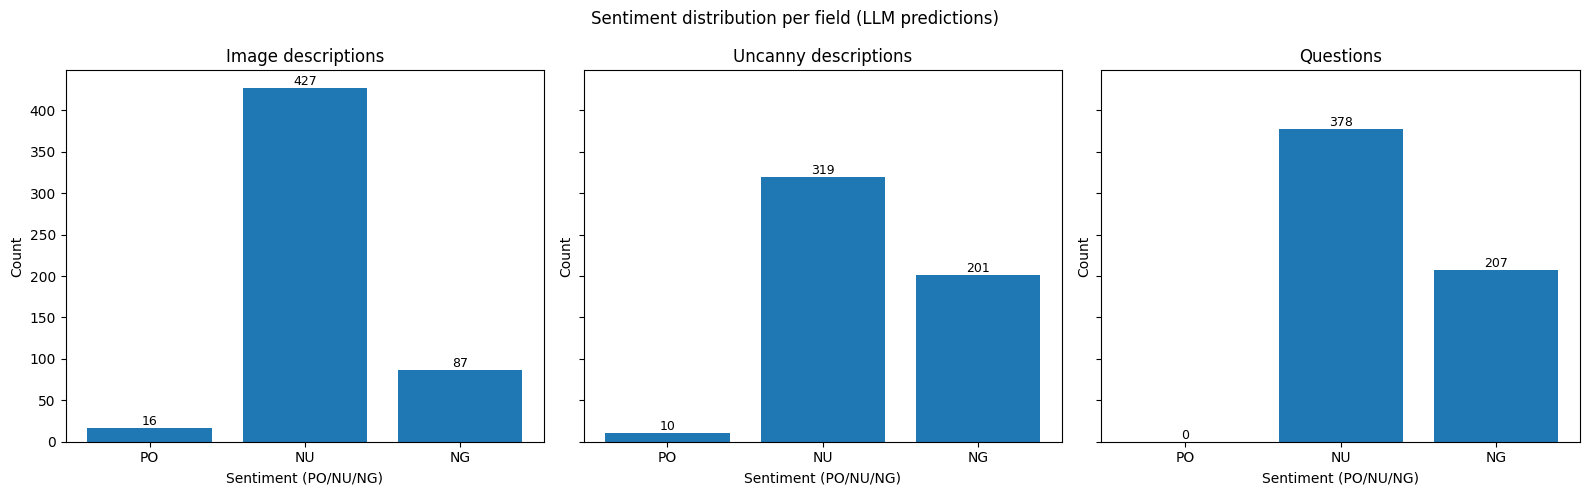

In [21]:
# --- Sentiment histograms (PO/NU/NG) for descriptions / uncanny / questions ---

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Inputs expected:
# df_descriptions, df_uncanny, df_questions  (exploded, one row per item with 'contest_id')
# desc_llm, uncanny_llm, questions_llm      (sentiment predictions with 'contest_id' and a sentiment column)

INCLUDE_UNKNOWN = False    # set True to keep "unknown" in the bars
ORDER_FULL = ["positive", "neutral", "negative"]
ORDER_CODES = ["PO", "NU", "NG"]

POSSIBLE_SENT_COLS = ["sentiment", "sentiment_label", "polarity", "label", "pred", "prediction"]

def normalize_sent(x: str) -> str:
    if x is None:
        return "unknown"
    s = str(x).strip().lower()
    mapping = {
        "pos": "positive", "positive": "positive", "1": "positive", "+1": "positive",
        "neu": "neutral",  "neutral": "neutral",  "0": "neutral",
        "neg": "negative", "negative": "negative", "-1": "negative"
    }
    if s in mapping: 
        return mapping[s]
    if s.startswith("po"):     return "positive"
    if s.startswith("neut"):   return "neutral"
    if s in {"ne", "nr"}:      return "neutral"   # safety nets
    if s.startswith("ne") or s.startswith("ng"): 
        return "negative"
    return "unknown"

def two_letter_sent(lab: str) -> str:
    lab = normalize_sent(lab)
    return {"positive":"PO", "neutral":"NU", "negative":"NG"}.get(lab, "??")

def ensure_idx(df: pd.DataFrame, contest_col="contest_id") -> pd.DataFrame:
    out = df.copy()
    out[contest_col] = pd.to_numeric(out[contest_col], errors="coerce").astype("Int64")
    out = out.sort_values([contest_col]).copy()
    if "idx" not in out.columns:
        out["idx"] = out.groupby(contest_col).cumcount()
    return out

def pick_sent_col(df: pd.DataFrame) -> str:
    for c in POSSIBLE_SENT_COLS:
        if c in df.columns:
            return c
    # fallback to first string-like non-key column
    for c in df.columns:
        if c not in {"contest_id", "idx"} and pd.api.types.is_string_dtype(df[c]):
            return c
    raise ValueError("No sentiment column found in the LLM dataframe.")

def counts_for(field_name, text_df, text_col, llm_df):
    base = text_df.dropna(subset=[text_col]).copy()
    base = ensure_idx(base, "contest_id")

    lab_raw = llm_df.copy()
    if "contest_id" not in lab_raw.columns:
        raise KeyError(f"{field_name}: LLM dataframe needs a 'contest_id' column.")
    sent_col = pick_sent_col(lab_raw)
    lab = lab_raw.copy()
    if "idx" not in lab.columns:
        lab = ensure_idx(lab, "contest_id")
    lab = lab[["contest_id", "idx", sent_col]]

    joined = base.merge(lab, on=["contest_id", "idx"], how="left")

    counts = Counter(normalize_sent(v) for v in joined[sent_col].dropna())
    if not INCLUDE_UNKNOWN:
        counts.pop("unknown", None)
    # return fixed order counts
    return [counts.get(k, 0) for k in ORDER_FULL]

# Build counts per field
desc_counts   = counts_for("image_descriptions",          df_descriptions, "image_descriptions",          desc_llm)
uncanny_counts= counts_for("image_uncanny_descriptions",  df_uncanny,      "image_uncanny_descriptions",  uncanny_llm)
quest_counts  = counts_for("questions",                   df_questions,    "questions",                   questions_llm)

# Plot: one histogram per field (grouped bars PO/NU/NG)
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fields = [
    ("Image descriptions", desc_counts),
    ("Uncanny descriptions", uncanny_counts),
    ("Questions", quest_counts),
]

for ax, (title, counts) in zip(axes, fields):
    ax.bar(ORDER_CODES, counts)
    ax.set_title(title)
    ax.set_xlabel("Sentiment (PO/NU/NG)")
    ax.set_ylabel("Count")
    # show bar values
    for x, y in zip(ORDER_CODES, counts):
        ax.text(x, y, str(y), ha="center", va="bottom", fontsize=9)

fig.suptitle("Sentiment distribution per field (LLM predictions)")
plt.tight_layout()
plt.show()